<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 4. Семинар 1.
# Тесты на единичный корень: ADF, KPSS и когда они спорят

В ноутбуке `01` мы научились *видеть* стационарность: по графику, по
сводным статистикам кусков ряда (`chunk_stats`) и по автокорреляционной
функции. Все три способа субъективны: «медленно затухает» или «не очень
медленно» — вопрос вкуса, и два человека легко дадут разные ответы на один
и тот же график.

Переходим к формальной процедуре — статистическим тестам. Но
главная мысль ноутбука не в том, «какую функцию вызвать»:

> 🔑 **Тест — не оракул.** У него есть спецификация (её нужно выбрать
> правильно, иначе ответ будет систематически неверным), есть мощность
> (на коротком ряду он почти не отличает $\varphi=0.95$ от единичного
> корня) и есть осмысленная зона отказа — ситуации, когда честный ответ
> звучит как «данных не хватает».

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 1 | Откуда вообще берётся слово «корень» в «единичном корне» |
| 2 | Тест ADF: уравнение, гипотезы, знак статистики, выбор лагов |
| 3 | Три спецификации `n` / `c` / `ct` и цена неверного выбора |
| 4 | KPSS: тест с противоположной нулевой гипотезой |
| 5 | Таблица 2×2 исходов: что делать при каждом сочетании ответов |
| 6 | Мощность тестов: Монте-Карло, почему тесту нельзя верить слепо |
| 7 | Phillips-Perron, DF-GLS, Zivot-Andrews — зачем существуют |
| 8 | Возврат к среднему ≠ стационарность (кейс: акции Google) |


In [2]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss, zivot_andrews
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning
import statsmodels

from utils import tsdisplay

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 100

print("statsmodels:", statsmodels.__version__)

statsmodels: 0.14.6


---
# 1. Откуда берётся «единичный корень»

Название теста звучит загадочно: при чём тут корни и почему именно
единица? Разберём это на AR(1) — процессе, который мы уже видели в
разделе 2.6 предыдущего ноутбука.

## 1.1. AR(1) через лаг-оператор

Авторегрессионный процесс первого порядка:

$$y_t = \varphi_1 y_{t-1} + \varepsilon_t$$

где $y_t$ — значение ряда в момент $t$, $\varphi_1$ — неизвестный
коэффициент, $\varepsilon_t$ — белый шум.

Введём **лаг-оператор** $L$, который сдвигает ряд на один шаг назад:
$L y_t = y_{t-1}$. Тогда $\varphi_1 y_{t-1} = \varphi_1 L y_t$, и всё
уравнение можно собрать в одну скобку:

$$(1 - \varphi_1 L)\, y_t = \varepsilon_t$$

Многочлен $1 - \varphi_1 L$ называется **характеристическим полиномом**
процесса AR(1). Слово «корень» относится именно к нему.

## 1.2. Корень характеристического уравнения

Приравняем полином к нулю и решим относительно $L$:

$$1 - \varphi_1 L = 0 \quad \Longrightarrow \quad L = \frac{1}{\varphi_1}$$

Это и есть корень характеристического уравнения. Теперь ключевое
наблюдение:

$$\varphi_1 = 1 \quad \Longleftrightarrow \quad L = 1$$

Корень равен **единице** — отсюда и название. А что означает $\varphi_1=1$
для самого ряда? Подставим в исходное уравнение:

$$y_t = y_{t-1} + \varepsilon_t$$

Это в точности случайное блуждание из раздела 2.2 ноутбука `01` — ряд с
растущей дисперсией $\mathrm{Var}(y_t) = t\sigma^2$, то есть заведомо
нестационарный.

> 🔑 **Цепочка, которую надо запомнить:**
> единичный корень $\Leftrightarrow$ $\varphi_1 = 1$ $\Leftrightarrow$
> случайное блуждание $\Leftrightarrow$ нестационарность $\Leftrightarrow$
> шок остаётся в ряду навсегда.

## 1.3. «Шок навсегда» — что это значит наглядно

Последнее звено цепочки стоит увидеть. Раскрутим AR(1) назад:

$$y_t = \varepsilon_t + \varphi_1 \varepsilon_{t-1} + \varphi_1^2 \varepsilon_{t-2} + \dots$$

Вклад шока, случившегося $h$ шагов назад, равен $\varphi_1^h$. При
$|\varphi_1| < 1$ это геометрически убывающая величина — влияние старых
шоков забывается. При $\varphi_1 = 1$ вклад равен $1^h = 1$ на любом
горизонте: ряд помнит каждый шок вечно.

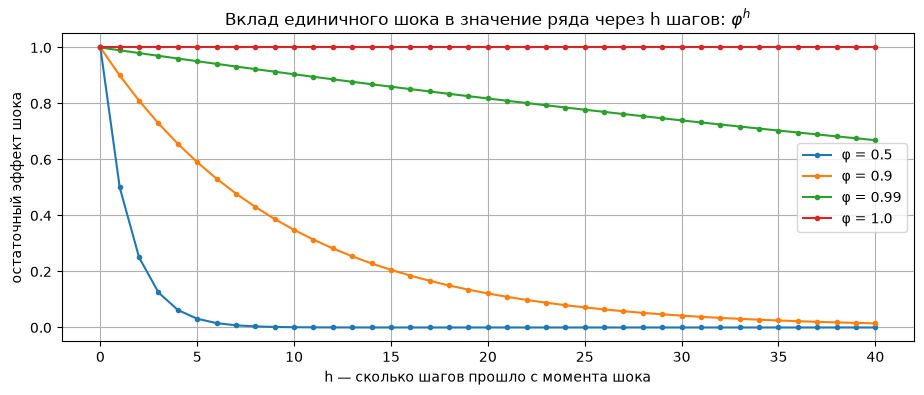

In [3]:
horizons = np.arange(0, 41)

plt.figure(figsize=(11, 4))
for phi in [0.5, 0.9, 0.99, 1.0]:
    plt.plot(horizons, phi**horizons, marker="o", ms=3, label=f"φ = {phi}")
plt.title("Вклад единичного шока в значение ряда через h шагов: $\\varphi^h$")
plt.xlabel("h — сколько шагов прошло с момента шока")
plt.ylabel("остаточный эффект шока")
plt.legend()
plt.show()

При $\varphi=0.5$ шок практически забывается за 10 шагов, при
$\varphi=0.9$ — примерно за 40. При $\varphi=1$ горизонтальная прямая на
уровне 1: эффект не затухает никогда, ряд «уходит» и не возвращается.

🔍 Обратите внимание на кривую $\varphi=0.99$: формально ряд стационарен
($|\varphi|<1$), но на горизонте в 40 шагов она почти неотличима от
прямой $\varphi=1$. Это первое предупреждение о том, к чему мы придём в
разделе 6: **разница между «стационарен с $\varphi=0.99$» и «единичный
корень» на данных конечной длины практически не наблюдаема.**

## 1.4. Как это выглядит на реализациях

Сгенерируем по одной траектории для каждого $\varphi$ и посмотрим, как
меняется поведение при приближении $\varphi$ к единице.

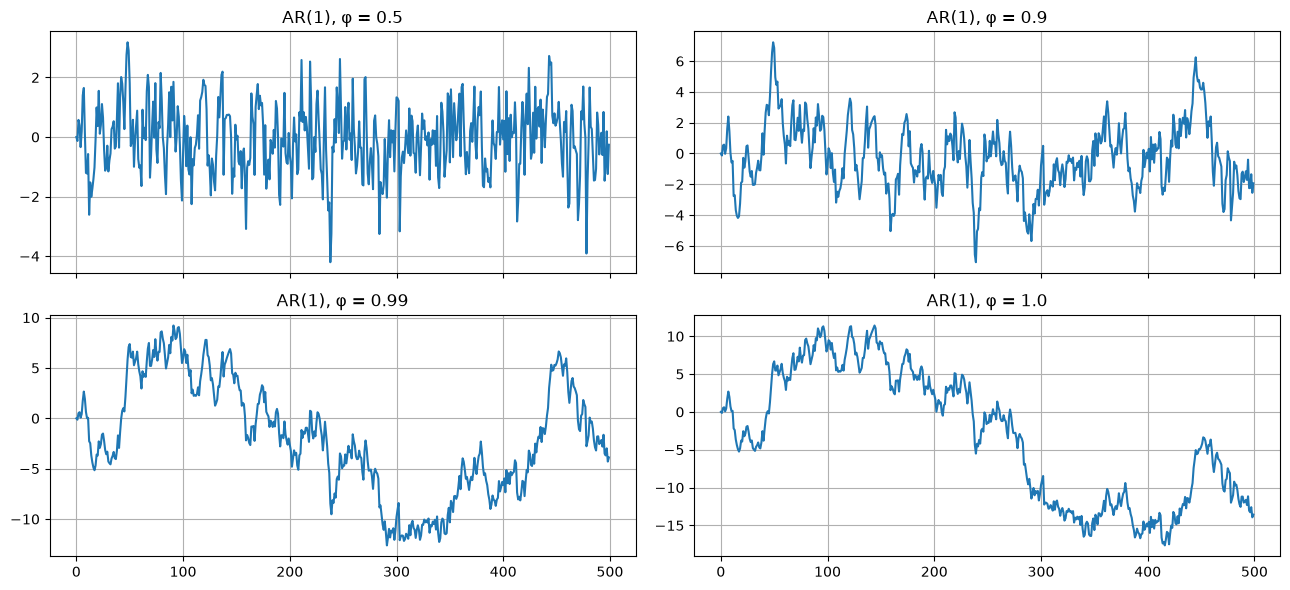

In [4]:
rng = np.random.default_rng(0)

n = 500
eps = rng.normal(size=n)  # одни и те же инновации для всех φ — чтобы сравнение было честным


def ar1_path(phi, innovations):
    """Траектория AR(1) с заданным φ на заданных инновациях, старт из нуля."""
    y = np.zeros(len(innovations))
    for t in range(1, len(innovations)):
        y[t] = phi * y[t - 1] + innovations[t]
    return pd.Series(y)


phis = [0.5, 0.9, 0.99, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for ax, phi in zip(axes.flat, phis):
    ar1_path(phi, eps).plot(ax=ax, title=f"AR(1), φ = {phi}")
plt.tight_layout()
plt.show()

Слева вверху ($\varphi=0.5$) ряд плотно жмётся к нулю. С ростом $\varphi$
отклонения становятся всё более длинными и «вязкими», а при $\varphi=1$
ряд просто уходит гулять — уровня, к которому он возвращается, больше нет.
Заметьте: **инновации во всех четырёх панелях одни и те же**, различается
только $\varphi$.

Задача теста на единичный корень — по такой картинке (а точнее, по числам
за ней) решить, лежим мы в верхнем ряду или в нижнем правом углу.

---
# 2. Тест ADF (Augmented Dickey-Fuller)

## 2.1. Идея

ADF — самый популярный тест на единичный корень. Основная идея: оценить,
насколько запаздывающее значение ряда помогает предсказывать *приращение*
ряда. Если помогает (есть возврат к уровню) — единичного корня нет; если
приращение никак не зависит от текущего уровня — это случайное блуждание.

Тест начинается с модели, включающей ряд с лагом 1, а затем в неё
добавляются лаги *разностей* — для контроля автокорреляции более высокого
порядка. Это и есть «augmented» (дополненная) часть названия: без неё был
бы обычный тест Дикки-Фуллера, применимый только к чистому AR(1).

## 2.2. Уравнение теста

$$\Delta y_t = \alpha + \beta t + \gamma\, y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \varepsilon_t$$

где

* $\Delta y_t = y_t - y_{t-1}$ — первая разность,
* $\alpha$ — константа (снос),
* $\beta t$ — детерминированный линейный тренд,
* $\gamma$ — коэффициент при запаздывающем **уровне** ряда — главный
  объект теста,
* $\delta_i$ — коэффициенты при запаздывающих разностях,
* $\varepsilon_t$ — ошибка.

## 2.3. Почему $\gamma$ — это то, что нужно

Возьмём чистый AR(1) без константы и тренда ($\alpha=\beta=0$, $\delta_i=0$)
и вычтем $y_{t-1}$ из обеих частей уравнения $y_t = \varphi_1 y_{t-1} + \varepsilon_t$:

$$y_t - y_{t-1} = (\varphi_1 - 1)\, y_{t-1} + \varepsilon_t
\quad\Longrightarrow\quad
\Delta y_t = \underbrace{(\varphi_1 - 1)}_{\gamma}\, y_{t-1} + \varepsilon_t$$

То есть $\boxed{\gamma = \varphi_1 - 1}$, и утверждение «единичный корень»
($\varphi_1=1$) превращается в удобное для проверки утверждение
$\gamma = 0$. Если $\gamma=0$, то $\Delta y_t = \varepsilon_t$ — приращения
суть белый шум, а сам ряд есть случайное блуждание.

## 2.4. Гипотезы

* $H_0$: $\gamma = 0$ — **у ряда есть единичный корень**, ряд нестационарен.
* $H_1$: $\gamma < 0$ — единичного корня нет.

🔍 Обратите внимание на два обстоятельства, из-за которых ADF чаще всего
читают неправильно:

1. **Нулевая гипотеза — это «нестационарен».** Маленькое p-value ⇒
   отвергаем $H_0$ ⇒ вывод «нестационарности не обнаружено». Большое
   p-value ⇒ $H_0$ **не отвергается**, что не равно «доказано, что ряд
   нестационарен»: возможно, просто не хватило данных.
2. **Альтернатива односторонняя:** $\gamma<0$, поэтому статистика
   сравнивается с критическими значениями «слева». Чем **более
   отрицательна** статистика, тем сильнее свидетельство против $H_0$.
   Если статистика отрицательнее критического значения — $H_0$ отвергается.

## 2.5. Выбор числа лагов $p$

Число лагов разностей в уравнении теста влияет на результат:

* слишком мало лагов — в остатках теста остаётся автокорреляция, и
  распределение статистики перестаёт соответствовать табличному;
* слишком много — тратятся степени свободы, мощность теста падает.

На практике $p$ подбирают по информационному критерию. В `statsmodels` за
это отвечает аргумент `autolag`: `'AIC'` (по умолчанию), `'BIC'`,
`'t-stat'` или `None` (тогда берётся ровно `maxlag` лагов).

## 2.6. Первый вызов

Проверим тест на ряде, про который мы точно знаем ответ, — на случайном
блуждании.

In [5]:
random_walk = pd.Series(100 + rng.normal(0, 1, 500).cumsum())

result = adfuller(random_walk, autolag="AIC")
adf_stat, p_value, usedlag, nobs, crit_values, icbest = result

print(f"ADF статистика:      {adf_stat: .3f}")
print(f"p-value:             {p_value: .3f}")
print(f"Использовано лагов:  {usedlag}")
print(f"Наблюдений в регрессии: {nobs}")
print("Критические значения:", {k: round(v, 2) for k, v in crit_values.items()})

ADF статистика:       0.977
p-value:              0.994
Использовано лагов:  0
Наблюдений в регрессии: 499
Критические значения: {'1%': np.float64(-3.44), '5%': np.float64(-2.87), '10%': np.float64(-2.57)}


p-value почти равен единице, статистика далека от критических значений —
она не «отрицательнее» их, а наоборот, ближе к нулю. $H_0$ о наличии
единичного корня **не отвергается**. Для случайного блуждания это верный
ответ.

Оформим вызов в функцию, чтобы дальше не повторять форматирование.

In [6]:
def adf_report(series, title="", regression="c", autolag="AIC"):
    """Одна строка результатов ADF — статистика, p-value, лаги, вердикт при α=5%."""
    stat, pval, usedlag, nobs, crit, _ = adfuller(series, regression=regression, autolag=autolag)
    return {
        "ряд": title,
        "spec": regression,
        "ADF": round(stat, 3),
        "p-value": round(pval, 4),
        "lags": usedlag,
        "крит. 5%": round(crit["5%"], 3),
        "вывод (α=5%)": "отвергаем H₀: ед. корня нет" if pval < 0.05 else "не отвергаем H₀: ед. корень",
    }

И сравним четыре ряда из раздела 1.4 — от заведомо стационарного до
заведомо нестационарного.

In [7]:
pd.DataFrame([adf_report(ar1_path(phi, eps), f"AR(1), φ = {phi}") for phi in phis]).set_index("ряд")

,spec,ADF,p-value,lags,крит. 5%,вывод (α=5%)
ряд,,,,,,
"AR(1), φ = 0.5",c,-13.287,0.0000,0,-2.867,отвергаем H₀: ед. корня нет
"AR(1), φ = 0.9",c,-5.507,0.0000,0,-2.867,отвергаем H₀: ед. корня нет
"AR(1), φ = 0.99",c,-2.039,0.2697,0,-2.867,не отвергаем H₀: ед. корень
"AR(1), φ = 1.0",c,-1.074,0.7252,0,-2.867,не отвергаем H₀: ед. корень


При $\varphi=0.5$ и $\varphi=0.9$ тест уверенно отвергает $H_0$ (p-value
на уровне нулей) — ряды опознаны как стационарные. При $\varphi=1.0$ не
отвергает — тоже верно.

А вот $\varphi=0.99$: p-value около 0.27, $H_0$ не отвергается, и тест
**ошибается** — ряд стационарен, единичного корня в нём нет. Это не баг
конкретной реализации и не следствие неудачного розыгрыша: по построению
(раздел 1.3) траектория с $\varphi=0.99$ на 500 точках почти неотличима
от случайного блуждания. Количественно разберём это в разделе 6.

---
# 3. Три спецификации: `n`, `c`, `ct`

Вернёмся к уравнению теста. В нём есть два «служебных» слагаемых —
константа $\alpha$ и тренд $\beta t$ — и от того, включаем мы их или нет,
зависят и оцениваемая регрессия, и таблица критических значений. Отсюда
три версии теста (аргумент `regression` в `adfuller`):

| `regression` | Уравнение содержит | Когда использовать |
|---|---|---|
| `'n'` | ни константы, ни тренда | ряд колеблется вокруг нуля |
| `'c'` | константу, без тренда | ряд колеблется вокруг ненулевого уровня (по умолчанию) |
| `'ct'` | константу и тренд | ряд может быть стационарен вокруг прямой |

(Есть ещё `'ctt'` — с квадратичным трендом, на практике почти не нужен.)

Что будет, если выбрать не ту спецификацию? Проверим экспериментально:
сгенерируем три заведомо **стационарных** (относительно своих
детерминированных компонент) ряда и прогоним по каждому все три версии
теста.

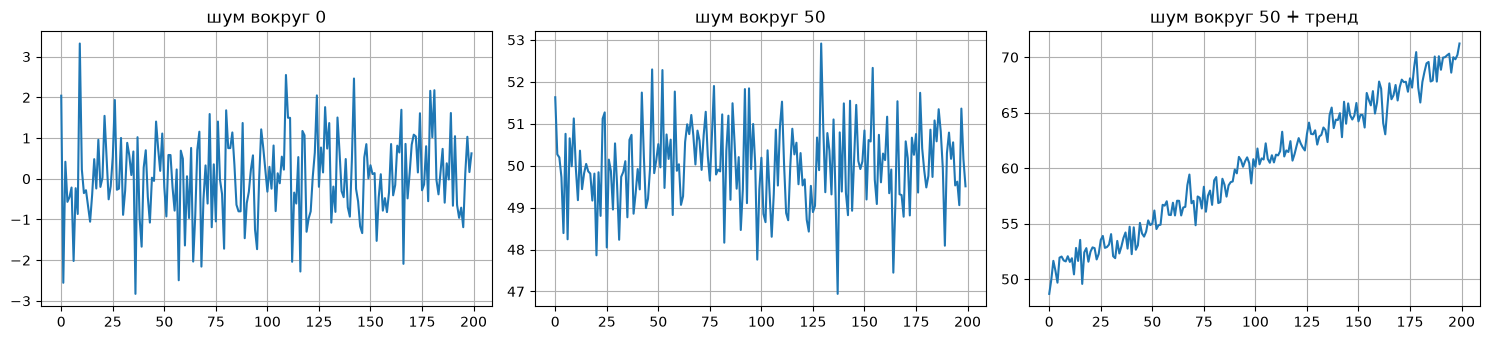

In [8]:
rng_spec = np.random.default_rng(3)
n_spec = 200

series_none = pd.Series(rng_spec.normal(0, 1, n_spec))
series_const = pd.Series(50 + rng_spec.normal(0, 1, n_spec))
series_const_trend = pd.Series(50 + np.linspace(0, 20, n_spec) + rng_spec.normal(0, 1, n_spec))

spec_series = {
    "шум вокруг 0": series_none,
    "шум вокруг 50": series_const,
    "шум вокруг 50 + тренд": series_const_trend,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, (name, s) in zip(axes, spec_series.items()):
    s.plot(ax=ax, title=name)
plt.tight_layout()
plt.show()

Все три ряда — это один и тот же белый шум, к которому добавлены разные
детерминированные компоненты: ничего (слева), константа (в центре),
константа и линейный тренд (справа). В каждом случае **шоки затухают
мгновенно**, единичного корня нет ни у одного из трёх. Тест обязан это
увидеть — если ему дать правильную спецификацию.

In [9]:
spec_table = pd.DataFrame(
    [[adfuller(s, regression=spec)[1] for spec in ["n", "c", "ct"]] for s in spec_series.values()],
    index=pd.Index(spec_series.keys(), name="ряд"),
    columns=pd.Index(["n", "c", "ct"], name="спецификация теста"),
)
spec_table.round(4).style.format("{:.4f}").background_gradient(cmap="RdYlGn_r", vmin=0, vmax=0.2)

спецификация теста,n,c,ct
ряд,,,
шум вокруг 0,0.0000,0.0000,0.0000
шум вокруг 50,0.6979,0.0000,0.0000
шум вокруг 50 + тренд,1.0000,0.9898,0.0000


Читаем таблицу (в клетках — p-value, зелёное = отвергаем $H_0$, то есть
«единичного корня нет»; красное = не отвергаем):

* **Первая строка** (шум вокруг нуля): все три спецификации отвергают
  $H_0$. Лишние константа и тренд оцениваются как незначимые и мешают
  мало — переспецификация стоит лишь небольшой потери мощности.
* **Вторая строка** (шум вокруг 50): спецификация `n` **не отвергает**
  $H_0$. Тест без константы вынужден объяснять уровень 50 через
  $\gamma\,y_{t-1}$, и единственный способ удержать ряд далеко от нуля —
  это $\gamma \approx 0$. Спецификации `c` и `ct` отрабатывают верно.
* **Третья строка** (шум вокруг 50 + тренд): не отвергают ни `n`, ни `c`.
  Только `ct`, где тренд явно вынесен в уравнение, даёт правильный ответ.

> 🔑 **Вывод.** Неверная (недостаточная) спецификация систематически не
> даёт отвергнуть $H_0$ — то есть заставляет объявить нестационарным ряд,
> который на самом деле стационарен. Ошибка смещена в одну сторону, и это
> делает её особенно опасной: вы «на всякий случай» возьмёте разность
> там, где она не нужна (к чему это приводит — раздел про
> сверхдифференцирование в ноутбуке `03`).

🔍 Практическое правило: **сначала посмотрите на график**, а уже потом
выбирайте `regression`. Есть видимый тренд — берите `ct`. Ряд колеблется
вокруг ненулевого уровня — `c` (значение по умолчанию, и в большинстве
задач оно разумно). `'n'` осмысленна практически только для приращений и
остатков — рядов, которые по построению крутятся вокруг нуля.

---
# 4. KPSS: тест с противоположной нулевой гипотезой

У ADF есть неудобное свойство, о котором мы говорили в разделе 2.4: его
$H_0$ — это «ряд нестационарен». В статистике нулевую гипотезу нельзя
«принять», её можно только не отвергнуть, поэтому ADF *в принципе* не
способен подтвердить стационарность — он может лишь не найти
доказательств обратного.

Тест **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) устроен зеркально:

| | ADF | KPSS |
|---|---|---|
| $H_0$ | есть единичный корень (нестационарен) | ряд стационарен |
| $H_1$ | единичного корня нет | есть единичный корень |
| маленькое p-value | ⇒ ряд похож на стационарный | ⇒ ряд похож на нестационарный |

🔍 **Это главный источник ошибок.** Одно и то же маленькое p-value у двух
тестов означает *противоположные* вещи. Всякий раз, читая вывод, проговаривайте
вслух, какая у теста нулевая гипотеза.

## 4.1. Как устроен KPSS

KPSS исходит из разложения ряда на три части:

$$y_t = \underbrace{\beta t}_{\text{тренд}} + \underbrace{r_t}_{\text{случайное блуждание}} + \underbrace{\varepsilon_t}_{\text{стационарный шум}}, \qquad r_t = r_{t-1} + u_t,\quad u_t \sim (0, \sigma_u^2)$$

Нулевая гипотеза — $\sigma_u^2 = 0$: компонента-блуждание вырождена в
константу, и от ряда остаётся тренд плюс стационарный шум. Статистика
строится по накопленным суммам остатков — если в ряду сидит блуждание,
эти суммы «разбегаются», и статистика становится большой.

У KPSS **две** спецификации, а не три:

* `regression='c'` — стационарность вокруг константы (по умолчанию),
* `regression='ct'` — стационарность вокруг линейного тренда.

Спецификации `'n'` нет: нулевая гипотеза «стационарен вокруг ничего» не
имеет смысла — уровень всегда есть, вопрос лишь в том, постоянный он или
линейно растущий.

🔍 Здесь тоже отвергают «справа»: чем **больше** статистика KPSS, тем
сильнее свидетельство против стационарности. Знак у неё, в отличие от ADF,
всегда положительный.

In [10]:
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(random_walk, regression="c", nlags="auto")

print(f"KPSS статистика: {kpss_stat:.3f}")
print(f"p-value:         {kpss_p:.3f}")
print(f"Лагов (Newey-West): {kpss_lags}")
print("Критические значения:", kpss_crit)

KPSS статистика: 2.784
p-value:         0.010
Лагов (Newey-West): 12
Критические значения: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


Статистика больше критического значения на 5%, p-value маленькое —
гипотеза о стационарности **отвергается**. Для случайного блуждания это,
опять же, правильный ответ; заметьте только, что «правильный» он теперь
при *маленьком* p-value, тогда как у ADF был при большом.

🔍 **Про p-value KPSS.** Библиотека печатает предупреждение
`p-value is smaller than the indicated p-value`, если статистика выходит
за пределы таблицы Kwiatkowski et al. (1992). Это не ошибка: p-value KPSS
интерполируется по таблице с четырьмя точками (10%, 5%, 2.5%, 1%), и вне
этого диапазона возвращается граничное значение 0.01 или 0.1. Поэтому у
KPSS осмысленно смотреть не столько на p-value, сколько на сравнение
статистики с критическими значениями.

## 4.2. Оба теста на одном ряду

Соберём вызовы вместе — так, как это и надо делать на практике.

In [11]:
def unit_root_report(series, title="", adf_spec="c", kpss_spec="c", alpha=0.05):
    """Совместный отчёт ADF + KPSS с готовым вердиктом по таблице 2×2."""
    adf_stat, adf_p, *_ = adfuller(series, regression=adf_spec, autolag="AIC")
    with warnings.catch_warnings():  # гасим InterpolationWarning, чтобы не засорять таблицу
        warnings.simplefilter("ignore", InterpolationWarning)
        kpss_stat, kpss_p, _, _ = kpss(series, regression=kpss_spec, nlags="auto")

    adf_unit_root = adf_p >= alpha  # H₀ ADF не отвергнута ⇒ единичный корень допускается
    kpss_stationary = kpss_p >= alpha  # H₀ KPSS не отвергнута ⇒ стационарность допускается

    verdict = {
        (True, True): "мало данных — вывода нет",
        (True, False): "нестационарен ⇒ нужна разность",
        (False, True): "стационарен",
        (False, False): "противоречие ⇒ ни то ни сё",
    }[(adf_unit_root, kpss_stationary)]

    return {
        "ряд": title,
        "ADF стат.": round(adf_stat, 3),
        "ADF p": round(adf_p, 4),
        "ADF: ед. корень?": "да" if adf_unit_root else "нет",
        "KPSS стат.": round(kpss_stat, 3),
        "KPSS p": round(kpss_p, 4),
        "KPSS: стационарен?": "да" if kpss_stationary else "нет",
        "вердикт": verdict,
    }

In [12]:
report_series = {
    "AR(1), φ = 0.5 (n=500)": ar1_path(0.5, eps),
    "AR(1), φ = 0.9 (n=500)": ar1_path(0.9, eps),
    "AR(1), φ = 0.99 (n=500)": ar1_path(0.99, eps),
    "случайное блуждание (n=500)": random_walk,
    "разность блуждания": random_walk.diff().dropna(),
    "AR(1), φ = 0.9, только n=50": ar1_path(0.9, eps).head(50),
}

pd.DataFrame([unit_root_report(s, name) for name, s in report_series.items()]).set_index("ряд")

,ADF стат.,ADF p,ADF: ед. корень?,KPSS стат.,KPSS p,KPSS: стационарен?,вердикт
ряд,,,,,,,
"AR(1), φ = 0.5 (n=500)",-13.287,0.0000,нет,0.122,0.1000,да,стационарен
"AR(1), φ = 0.9 (n=500)",-5.507,0.0000,нет,0.236,0.1000,да,стационарен
"AR(1), φ = 0.99 (n=500)",-2.039,0.2697,да,1.402,0.0100,нет,нестационарен ⇒ нужна разность
случайное блуждание (n=500),0.977,0.9940,да,2.784,0.0100,нет,нестационарен ⇒ нужна разность
разность блуждания,-21.547,0.0000,нет,0.341,0.1000,да,стационарен
"AR(1), φ = 0.9, только n=50",0.578,0.9871,да,0.423,0.0672,да,мало данных — вывода нет


Разберём таблицу построчно — в ней встретились три из четырёх возможных
исходов, которые мы формализуем в следующем разделе.

* **$\varphi=0.5$ и $\varphi=0.9$**: ADF отвергает единичный корень, KPSS
  не отвергает стационарность. Оба теста согласны — **стационарен**.
  Правильный ответ.
* **$\varphi=0.99$**: оба теста согласны в обратную сторону —
  **нестационарен**. И оба ошибаются: ряд стационарен по построению.
  Согласие двух тестов не является гарантией правильности, если данных
  недостаточно, чтобы различить гипотезы.
* **Случайное блуждание**: **нестационарен**, и это верно.
* **Разность блуждания**: та же самая траектория после одной разности
  опознаётся обоими тестами как стационарная. Это ровно тот шаг, ради
  которого в ARIMA($p$,$d$,$q$) существует параметр $d$.
* **$\varphi=0.9$, но только первые 50 наблюдений**: ADF не может
  отвергнуть единичный корень, KPSS не может отвергнуть стационарность —
  каждый тест не отверг свою $H_0$, а они противоположны. Честный вывод:
  **данных не хватает**. Сравните со второй строкой — это *тот же самый*
  ряд, просто обрезанный.

🔍 Пятидесяти точек не хватило, чтобы опознать даже $\varphi=0.9$ —
ряд, который на 500 наблюдениях опознавался с p-value порядка нулей.
Длина ряда влияет на выводы теста не меньше, чем сами данные.

---
# 5. Таблица 2×2: что делать при каждом сочетании ответов

Формализуем логику, зашитую в `unit_root_report`. Два теста дают четыре
сочетания:

| | **KPSS: стационарен** (H₀ не отвергнута) | **KPSS: отвергает** стационарность |
|---|---|---|
| **ADF: есть ед. корень** (H₀ не отвергнута) | ❔ Мало данных — вывода нет | 🔴 Нестационарен ⇒ **берём разность** |
| **ADF: нет ед. корня** | 🟢 Стационарен — можно моделировать как есть | ⚠️ Противоречие ⇒ ни то ни сё |

Разберём все четыре клетки.

**🟢 «Стационарен».** Оба теста согласны. Разность не нужна, в ARIMA
берём $d=0$.

**🔴 «Нестационарен».** Оба теста согласны в обратную сторону. Берём
разность и **прогоняем тесты заново** на продифференцированном ряду — там
может понадобиться ещё одна ($d=2$). Автоматизацией этой процедуры
(«тест → разность → тест») займёмся в ноутбуке `03`. Помните при этом
строку $\varphi=0.99$ из предыдущей таблицы: согласие двух тестов —
сильный, но не безошибочный аргумент.

**❔ «Мало данных».** Ни один тест не смог отвергнуть свою нулевую
гипотезу — данные совместимы и со стационарностью, и с единичным корнем.
Это честный ответ «не знаю», а не повод выбрать понравившийся вариант.
Ровно этот случай мы видели на обрезанном до 50 точек AR(1). Что делать:
смотреть на график и ACF, опираться на предметные соображения (у ряда
*должен* быть постоянный уровень?), пробовать обе модели и сравнивать по
качеству прогноза на отложенной выборке.

**⚠️ «Противоречие».** Самая содержательная клетка: оба теста уверенно
отвергли свои $H_0$, что логически несовместимо. Значит, нарушено
какое-то из предположений, общих для обоих тестов. Типичные причины:

1. **Нестабильная дисперсия** — тесты предполагают гомоскедастичность.
   Лечится преобразованием (лог, Бокс-Кокс), а не разностью.
2. **Структурный сдвиг уровня** — ступенька в середине ряда «читается»
   тестами как медленно затухающая память. Лечится включением ступенчатой
   экзогенной переменной, а не разностью.
3. **Неверная спецификация** — например, ряд стационарен вокруг тренда, а
   оба теста запущены со спецификацией `'c'`.

🔍 Первым делом при противоречии стоит перезапустить оба теста с
`regression='ct'`. Если после этого ADF отвергает $H_0$, а KPSS — нет,
ряд **стационарен вокруг тренда**, и правильное лечение — детрендирование,
а не разность. Проверим это на ряде из раздела 3.

In [13]:
pd.DataFrame(
    [
        unit_root_report(series_const_trend, "шум + тренд, spec='c'", adf_spec="c", kpss_spec="c"),
        unit_root_report(series_const_trend, "шум + тренд, spec='ct'", adf_spec="ct", kpss_spec="ct"),
    ]
).set_index("ряд")

,ADF стат.,ADF p,ADF: ед. корень?,KPSS стат.,KPSS p,KPSS: стационарен?,вердикт
ряд,,,,,,,
"шум + тренд, spec='c'",0.697,0.9898,да,2.106,0.01,нет,нестационарен ⇒ нужна разность
"шум + тренд, spec='ct'",-13.473,0.0000,нет,0.063,0.10,да,стационарен


Со спецификацией `'c'` картина выглядит как «нестационарен, нужна
разность»: ADF не отвергает единичный корень, KPSS отвергает
стационарность вокруг константы. Со спецификацией `'ct'` тот же ряд
опознаётся как стационарный — потому что он и есть стационарный шум
вокруг прямой. Разность здесь была бы лечением не той болезни.

🔍 Причина, по которой мы вообще не могли увидеть это сразу: KPSS с
`'c'` **обязан** отвергнуть $H_0$ на ряде с трендом — тренд не является
стационарностью вокруг константы, и тест абсолютно прав. Он ответил на
другой вопрос, а не на тот, который мы имели в виду.


---
# 6. Мощность тестов: Монте-Карло

До сих пор мы смотрели на отдельные реализации. Но у теста есть
характеристика, которую по одной реализации не увидеть, — **мощность**:
вероятность отвергнуть $H_0$, когда $H_0$ действительно ложна.

Поставим эксперимент. Сгенерируем много независимых AR(1) с известным
$\varphi$ и посчитаем, в какой доле случаев ADF отвергает единичный корень
на уровне 5%. Возьмём $\varphi \in \{0.8,\ 0.9,\ 0.95,\ 0.99,\ 1.0\}$ и
две длины ряда: $n=100$ и $n=500$.

Как читать результат:

* при $\varphi < 1$ единичного корня нет, $H_0$ ложна — доля отвержений
  это **мощность**, и чем она выше, тем лучше;
* при $\varphi = 1$ $H_0$ верна — доля отвержений это **уровень значимости**,
  и он должен быть близок к номинальным 5%.

In [14]:
def rejection_rate(phi, n_obs, n_rep=300, alpha=0.05, regression="c", seed=0):
    """Доля отвержений H₀ теста ADF на n_rep независимых AR(1) с данным φ."""
    rng = np.random.default_rng(seed)
    rejections = 0
    for _ in range(n_rep):
        innovations = rng.normal(size=n_obs + 100)  # +100 на burn-in
        y = ar1_path(phi, innovations).to_numpy()[100:]
        if adfuller(y, regression=regression, autolag="AIC")[1] < alpha:
            rejections += 1
    return rejections / n_rep

In [15]:
phi_grid = [0.8, 0.9, 0.95, 0.99, 1.0]
power = pd.DataFrame(
    {f"n = {n_obs}": [rejection_rate(phi, n_obs) for phi in phi_grid] for n_obs in [100, 500]},
    index=pd.Index(phi_grid, name="φ"),
)
power

,n = 100,n = 500
φ,,
0.80,0.856667,1.000000
0.90,0.383333,0.996667
0.95,0.166667,0.943333
0.99,0.063333,0.116667
1.00,0.036667,0.050000


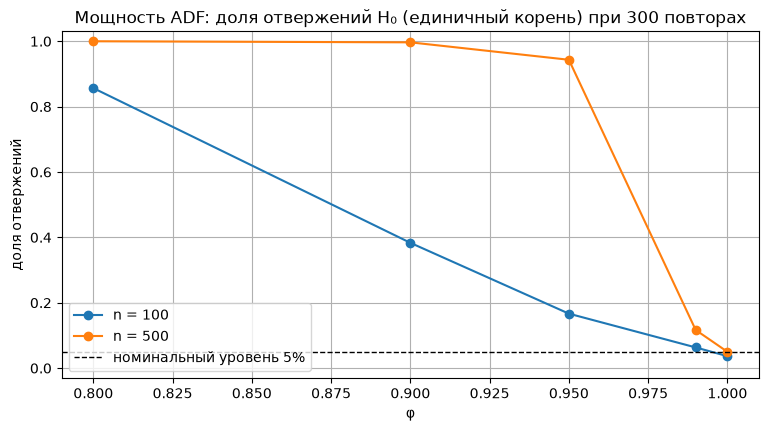

In [16]:
ax = power.plot(marker="o", figsize=(9, 4.5))
ax.axhline(0.05, color="black", ls="--", lw=1, label="номинальный уровень 5%")
ax.set_title("Мощность ADF: доля отвержений H₀ (единичный корень) при 300 повторах")
ax.set_ylabel("доля отвержений")
ax.set_ylim(-0.03, 1.03)
ax.legend()
plt.show()

Что видно на графике:

* **$\varphi = 1$ (правый край).** Доля отвержений держится около 0.05 при
  обеих длинах — тест корректно откалиброван, ложных тревог ровно столько,
  сколько мы заказали уровнем значимости.
* **$\varphi = 0.99$, $n=100$.** Доля отвержений почти не отличается от
  уровня значимости. Иначе говоря, **на ста наблюдениях ADF не отличает
  $\varphi=0.99$ от единичного корня вообще**. И это не недостаток
  реализации: ряды с $\varphi=0.99$ и $\varphi=1$ на 100 точках выглядят
  практически одинаково (вспомните раздел 1.3).
* **$\varphi = 0.95$, $n=100$ против $n=500$.** Мощность растёт с длиной
  ряда очень заметно. Данные — единственное, что реально помогает.
* **$\varphi = 0.8$.** Даже на коротком ряду тест справляется уверенно —
  с «явно стационарными» рядами проблем нет.

> 🔑 **Практический вывод.** «ADF не отверг $H_0$» — это НЕ «доказано, что
> ряд нестационарен». Особенно на коротких рядах это чаще всего значит
> «данных не хватило». Поэтому тесты используют вместе с графиком и ACF,
> а не вместо них, и поэтому в таблице 2×2 есть клетка «вывода нет».

🔍 Кстати, отсюда же понятно, почему в практических рекомендациях
(Hyndman) выбор $d$ делают по **KPSS**, а не по ADF: при выборе порядка
разности осторожнее ошибиться в сторону «взять разность», а $H_0$ у KPSS
устроена как раз так, что по умолчанию ряд считается стационарным и
разность добавляется только при явных свидетельствах против.

---
# Итоги

* **Единичный корень** — это корень $L=1/\varphi_1$ характеристического
  полинома AR(1), равный единице при $\varphi_1=1$. Цепочка эквивалентностей:
  единичный корень ⇔ случайное блуждание ⇔ нестационарность ⇔ шок
  остаётся в ряду навсегда (раздел 1).
* **ADF** проверяет $H_0$: $\gamma=\varphi_1-1=0$, то есть «единичный
  корень есть». Маленькое p-value ⇒ единичного корня нет. Статистика
  сравнивается «слева»: чем отрицательнее, тем сильнее свидетельство
  против $H_0$ (раздел 2).
* **Спецификация решает всё.** Недостаточная (`n` вместо `c`, `c` вместо
  `ct`) систематически мешает отвергнуть $H_0$ и толкает к лишней
  разности. Выбирайте `regression` после взгляда на график (раздел 3).
* **KPSS** зеркален ADF: $H_0$ — «ряд стационарен». Маленькое p-value
  значит противоположное тому, что у ADF (раздел 4).
* **Таблица 2×2** (раздел 5) даёт четыре осмысленных исхода, включая
  честное «вывода нет» и «противоречие» — последнее чаще всего лечится
  не разностью, а спецификацией `'ct'`, преобразованием дисперсии или
  учётом структурного сдвига.
* **Мощность.** На $n=100$ ADF практически не отличает $\varphi=0.95$–$0.99$
  от единичного корня (раздел 6). «Не отвергли $H_0$» ≠ «доказали $H_0$».
